In [347]:
# Data Processing
import pandas as pd
import numpy as np

# Modeling
from random import randint
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

from sklearn.inspection import permutation_importance
from sklearn.neural_network import  MLPRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.inspection import PartialDependenceDisplay
# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,mean_squared_error, r2_score
from sklearn.metrics import RocCurveDisplay

import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
#Read In Data
lc =  pd.read_csv("LC_HW2.csv")

In [43]:
lc

,all_util,annual_inc,application_type,chargeoff_within_12_mths,collections_12_mths_ex_med,delinq_2yrs,dti,emp_length,fico_range_high,fico_range_low,...,mo_sin_old_rev_tl_op,mort_acc,mths_since_last_record,mths_since_recent_inq,open_acc,pub_rec_bankruptcies,term,total_bal_ex_mort,verification_status,int_rate
0,80.0,36000.0,Individual,0,0,0,26.33,NaN,674,670,...,35,0,NaN,0.0,5,0,36 months,34683,Verified,18.62
1,61.0,45000.0,Individual,0,0,0,38.51,1 year,734,730,...,103,0,NaN,0.0,14,0,60 months,63873,Not Verified,16.08
2,31.0,53040.0,Individual,0,0,0,25.20,< 1 year,809,805,...,145,4,NaN,0.0,9,0,36 months,24452,Verified,7.56
3,87.0,125000.0,Individual,0,0,0,27.87,10+ years,684,680,...,230,4,NaN,19.0,14,0,36 months,141033,Verified,17.30
4,75.0,73000.0,Individual,0,0,0,35.12,10+ years,759,755,...,126,1,NaN,13.0,19,0,36 months,160302,Not Verified,10.81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,75.0,38500.0,Joint App,0,0,0,51.75,2 years,664,660,...,101,1,NaN,6.0,17,0,60 months,45338,Verified,18.62
99996,59.0,165000.0,Individual,0,0,3,12.90,6 years,714,710,...,212,4,NaN,14.0,14,0,36 months,55842,Not Verified,8.19
99997,54.0,49999.0,Individual,0,0,0,32.67,< 1 year,664,660,...,100,0,NaN,NaN,14,0,60 months,36970,Verified,17.74
99998,54.0,62800.0,Individual,0,0,0,33.86,1 year,759,755,...,143,2,NaN,1.0,15,0,60 months,92636,Verified,8.19


# Pre-process

In [45]:
lc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   all_util                    99984 non-null   float64
 1   annual_inc                  100000 non-null  float64
 2   application_type            100000 non-null  object 
 3   chargeoff_within_12_mths    100000 non-null  int64  
 4   collections_12_mths_ex_med  100000 non-null  int64  
 5   delinq_2yrs                 100000 non-null  int64  
 6   dti                         99814 non-null   float64
 7   emp_length                  91331 non-null   object 
 8   fico_range_high             100000 non-null  int64  
 9   fico_range_low              100000 non-null  int64  
 10  home_ownership              100000 non-null  object 
 11  inq_last_12m                100000 non-null  int64  
 12  loan_amnt                   100000 non-null  int64  
 13  mo_sin_old_il_a

In [ ]:
#Fix Employee Length

In [47]:
def clean_emp_length(val):
    if pd.isnull(val):
        return None
    elif val == '< 1 year':
        return 0
    elif val == '10+ years':
        return 10
    else:
        return int(val.strip().split()[0])

lc['emp_length'] = lc['emp_length'].apply(clean_emp_length)

In [55]:
lc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   all_util                    99984 non-null   float64
 1   annual_inc                  100000 non-null  float64
 2   application_type            100000 non-null  object 
 3   chargeoff_within_12_mths    100000 non-null  int64  
 4   collections_12_mths_ex_med  100000 non-null  int64  
 5   delinq_2yrs                 100000 non-null  int64  
 6   dti                         99814 non-null   float64
 7   emp_length                  91331 non-null   float64
 8   fico_range_high             100000 non-null  int64  
 9   fico_range_low              100000 non-null  int64  
 10  home_ownership              100000 non-null  object 
 11  inq_last_12m                100000 non-null  int64  
 12  loan_amnt                   100000 non-null  int64  
 13  mo_sin_old_il_a

In [ ]:
#Factor Categorical Variables

In [53]:
lc["term"] = lc["term"].astype("category").cat.codes

In [ ]:
lc["application_type"] =lc["application_type"].astype("category").cat.codes

In [59]:
lc["home_ownership"] = lc["home_ownership"].astype("category").cat.codes

In [72]:
lc["verification_status"] = lc["verification_status"].astype("category").cat.codes

In [61]:
#Look at NA's

In [64]:
lc.isna().sum()

all_util                         16
annual_inc                        0
application_type                  0
chargeoff_within_12_mths          0
collections_12_mths_ex_med        0
delinq_2yrs                       0
dti                             186
emp_length                     8669
fico_range_high                   0
fico_range_low                    0
home_ownership                    0
inq_last_12m                      0
loan_amnt                         0
mo_sin_old_il_acct             2204
mo_sin_old_rev_tl_op              0
mort_acc                          0
mths_since_last_record        90875
mths_since_recent_inq          9975
open_acc                          0
pub_rec_bankruptcies              0
term                              0
total_bal_ex_mort                 0
verification_status               0
int_rate                          0
dtype: int64

In [ ]:
#Removing mths_since_last_record since there are 90,0000 missing values

In [68]:
lc.drop("mths_since_last_record",axis = 1, inplace =True)

In [70]:
lc.isna().sum()

all_util                        16
annual_inc                       0
application_type                 0
chargeoff_within_12_mths         0
collections_12_mths_ex_med       0
delinq_2yrs                      0
dti                            186
emp_length                    8669
fico_range_high                  0
fico_range_low                   0
home_ownership                   0
inq_last_12m                     0
loan_amnt                        0
mo_sin_old_il_acct            2204
mo_sin_old_rev_tl_op             0
mort_acc                         0
mths_since_recent_inq         9975
open_acc                         0
pub_rec_bankruptcies             0
term                             0
total_bal_ex_mort                0
verification_status              0
int_rate                         0
dtype: int64

# Exploratory Data Analysis

In [77]:
lc.describe()

,all_util,annual_inc,chargeoff_within_12_mths,collections_12_mths_ex_med,delinq_2yrs,dti,emp_length,fico_range_high,fico_range_low,home_ownership,...,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mort_acc,mths_since_recent_inq,open_acc,pub_rec_bankruptcies,term,total_bal_ex_mort,verification_status,int_rate
count,99984.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,99814.000000,91331.000000,100000.000000,100000.00000,100000.000000,...,97796.000000,100000.000000,100000.000000,90025.000000,100000.00000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000
mean,55.106917,8.851942e+04,0.005980,0.014850,0.219360,21.611879,5.308176,710.608190,706.60805,0.918440,...,126.835832,172.027700,1.359510,7.007265,12.13205,0.092590,0.344580,6.072311e+04,0.469090,12.946763
std,20.141329,9.509197e+04,0.088455,0.134051,0.722998,19.836792,3.839157,35.617426,35.61688,0.934921,...,58.609836,99.388352,1.759902,5.839270,6.08440,0.296037,0.475234,5.833160e+04,0.499046,5.255559
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,664.000000,660.00000,0.000000,...,0.000000,5.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000e+00,0.000000,6.460000
25%,41.000000,5.000000e+04,0.000000,0.000000,0.000000,13.400000,2.000000,684.000000,680.00000,0.000000,...,86.000000,97.000000,0.000000,2.000000,8.00000,0.000000,0.000000,2.493875e+04,0.000000,8.190000
50%,55.500000,7.300000e+04,0.000000,0.000000,0.000000,19.770000,5.000000,704.000000,700.00000,1.000000,...,131.000000,156.000000,1.000000,5.000000,11.00000,0.000000,0.000000,4.482400e+04,0.000000,11.710000
75%,69.000000,1.050000e+05,0.000000,0.000000,0.000000,26.980000,10.000000,729.000000,725.00000,2.000000,...,162.000000,223.000000,2.000000,10.000000,15.00000,0.000000,1.000000,7.690500e+04,1.000000,16.120000
max,185.000000,8.645185e+06,6.000000,10.000000,19.000000,999.000000,10.000000,850.000000,845.00000,2.000000,...,722.000000,914.000000,32.000000,25.000000,69.00000,7.000000,1.000000,1.235436e+06,1.000000,30.990000


<Axes: xlabel='term', ylabel='int_rate'>

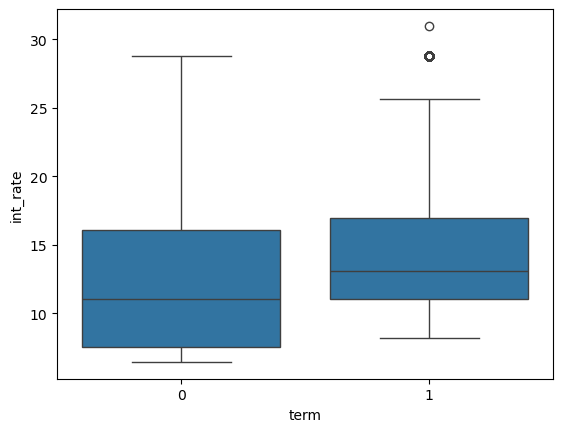

In [85]:
sns.boxplot(x='term', y='int_rate', data=lc)

<Axes: xlabel='annual_inc', ylabel='int_rate'>

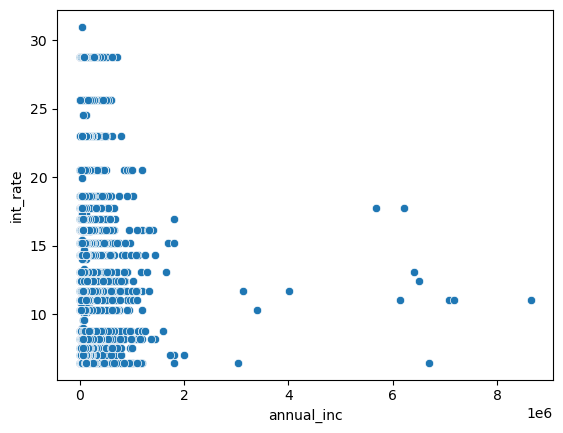

In [93]:
sns.scatterplot(x='annual_inc', y='int_rate', data=lc)

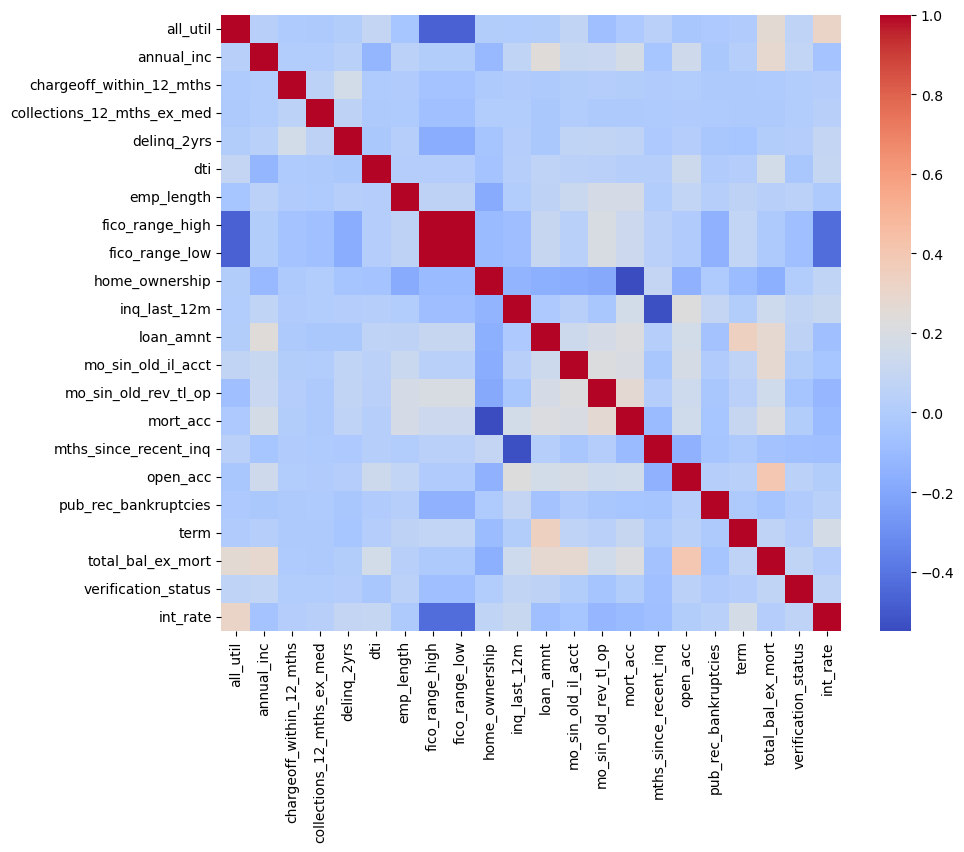

In [103]:

corr = lc.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.show()

# Model Building

In [109]:
#Features data: select all columns except 'Churn'
X = lc.loc[:, lc.columns!="int_rate"]

#Response/target data
Y = lc[["int_rate"]]

# Split data into training and test set
X_train, X_test, Y_train, Y_test = train_test_split(X,
                                                    Y,
                                                    test_size=0.25,    # hold out 25% of data for testing
                                                    random_state=123) # set for reproducibility

In [111]:
#median imputation for missing values

In [208]:
numeric_cols = X_train.select_dtypes(include='number').columns
non_numeric_cols = X_train.select_dtypes(exclude='number').columns

# Impute only the numeric columns
imputer = SimpleImputer(strategy='median')
X_train[numeric_cols] = imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = imputer.transform(X_test[numeric_cols])


In [210]:
X_train.isna().sum()

all_util                      0
annual_inc                    0
chargeoff_within_12_mths      0
collections_12_mths_ex_med    0
delinq_2yrs                   0
dti                           0
emp_length                    0
fico_range_high               0
fico_range_low                0
home_ownership                0
inq_last_12m                  0
loan_amnt                     0
mo_sin_old_il_acct            0
mo_sin_old_rev_tl_op          0
mort_acc                      0
mths_since_recent_inq         0
open_acc                      0
pub_rec_bankruptcies          0
term                          0
total_bal_ex_mort             0
verification_status           0
application_type_Joint App    0
dtype: int64

# Model Fitting

In [ ]:
One Hot encode because algorithm doesnt fit

In [136]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=123)

#one-hot encode
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [146]:
RFreg = RandomForestRegressor(random_state=0)
RFreg.fit(X_train, np.ravel(Y_train))

RandomForestRegressor(random_state=0)

In [157]:
# Make predictions using the model and the testing data
Y_pred = RFreg.predict(X_test)


print("R²:", r2_score(Y_test, Y_pred))
print("RMSE:", mean_squared_error(Y_test, Y_pred, squared=False))



R²: 0.35644541215967074
RMSE: 4.2233521077409115


C:\Users\sscal\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


# Hyper Parameter Tuning

In [173]:
# Using a randomized grid search to find the best set of parameters
# Setting ranges for parameters of interest
# max_features: number of variables to consider when looking for the best split (default=sqrt(p)) (equivalent of mtry in R)
# n_estimators: number of trees in the forest (default=100) (equivalent of ntree in R)
param_dist = {'max_features': range(1,min(9,X_train.shape[1]+1)),
              'n_estimators': range(10,100,10)
             }

# Use random search to find the best hyperparameters
# n_iter: number of parameter settings that are randomly sampled
# cv: number of folds for cross validation (if none, the default value of 5 will be used)
rand_search = RandomizedSearchCV(RFreg, 
                                 param_distributions = param_dist,
                                 n_iter=5,
                                 cv=5,
                                 random_state=0,
                                 verbose=False
                                )

# Fit the random search object to the data
rand_search.fit(X_train, np.ravel(Y_train))

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=0),
                   n_iter=5,
                   param_distributions={'max_features': range(1, 9),
                                        'n_estimators': range(10, 100, 10)},
                   random_state=0, verbose=False)

In [323]:
best_rf = rand_search.best_estimator_

# Print the best hyperparameters
print('Best hyperparameters:',  rand_search.best_params_)

Best hyperparameters: {'n_estimators': 90, 'max_features': 3}


In [325]:
Y_pred_tuned = best_rf.predict(X_test)

In [327]:
print("R²:", r2_score(Y_test, Y_pred_tuned))
print("RMSE:", mean_squared_error(Y_test, Y_pred_tuned, squared=False))

R²: 0.3504813152611752
RMSE: 4.242876785538932


C:\Users\sscal\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


# Regression Tree

In [287]:
DTreg = DecisionTreeRegressor(random_state=0) 
DTreg = DTreg.fit(X_train, Y_train)

# To get the depth of the tree that was trained:
DTreg.get_depth()

43

In [301]:
Y_pred_tree = DTreg.predict(X_test)

# Report accuracy measures
rmse_dt = mean_squared_error(Y_test, Y_pred_tree, squared=False)
print("RMSE:", rmse)

r2_dt = r2_score(Y_test, Y_pred_tree)

print("R2 Score:",r2_dt)

RMSE: 4.423687220699478
R2 Score: -0.3130099118289251


C:\Users\sscal\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


# Hyper Parameter Tuning for Decision Tree

In [310]:

param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10],
    'max_features': [None, 'sqrt', 'log2']
}

grid_search = GridSearchCV(
    DTreg,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',  # or use 'r2' if optimizing R²
    cv=5,
    n_jobs=-1,
    verbose=1
)


In [312]:

grid_search.fit(X_train, Y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=0), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 10, None],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 5, 10],
                         'min_samples_split': [2, 5, 10]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [379]:
best_tree = grid_search.best_estimator_
Y_pred_tree_tuned = best_tree.predict(X_test)

best_tree

DecisionTreeRegressor(max_depth=10, min_samples_leaf=10, random_state=0)

In [318]:
rmse_tree_tuned = mean_squared_error(Y_test, Y_pred_tree_tuned, squared=False)
r2_tree_tuned= r2_score(Y_test, Y_pred_tree_tuned)

print("RMSE:", rmse_tree_tuned)
print("R² Score:", r2_tree_tuned)

RMSE: 4.388157660395386
R² Score: 0.3052392829636972


C:\Users\sscal\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


# Interpreting our Best Model

## Permutation Importance

In [333]:
result = permutation_importance(best_rf, X_train, Y_train, n_repeats=1, random_state=123, n_jobs=2)

# Create a DataFrame for permutation importances
feature_names = X_train.columns #Reading feature names from the training data (which is a df)
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': result.importances_mean})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
print(importance_df)

                       Feature  Importance
5                          dti    0.311726
7              fico_range_high    0.294057
0                     all_util    0.278835
8               fico_range_low    0.266228
18                        term    0.259911
11                   loan_amnt    0.153083
13        mo_sin_old_rev_tl_op    0.139234
1                   annual_inc    0.138770
19           total_bal_ex_mort    0.125260
10                inq_last_12m    0.120209
12          mo_sin_old_il_acct    0.107449
15       mths_since_recent_inq    0.102540
14                    mort_acc    0.098425
16                    open_acc    0.091704
9               home_ownership    0.077541
6                   emp_length    0.075385
20         verification_status    0.059599
4                  delinq_2yrs    0.042430
21  application_type_Joint App    0.037223
17        pub_rec_bankruptcies    0.015234
3   collections_12_mths_ex_med    0.002317
2     chargeoff_within_12_mths    0.000643


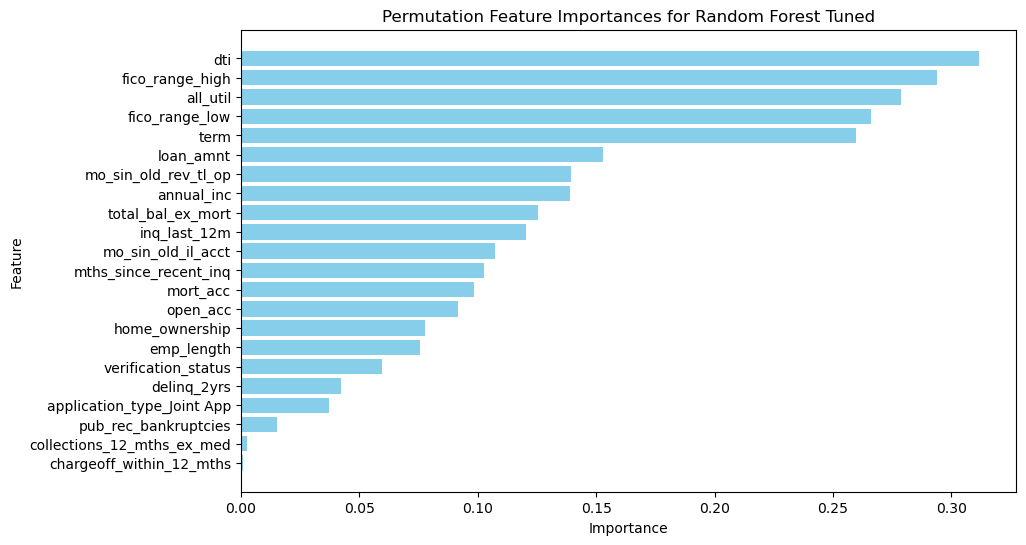

In [376]:
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Permutation Feature Importances for Random Forest Tuned')
plt.gca().invert_yaxis()  
plt.show()

# Partial Dependence Plots

In [357]:
top_features = importance_df['Feature'].head(2).tolist()
print(top_features)

['dti', 'fico_range_high']


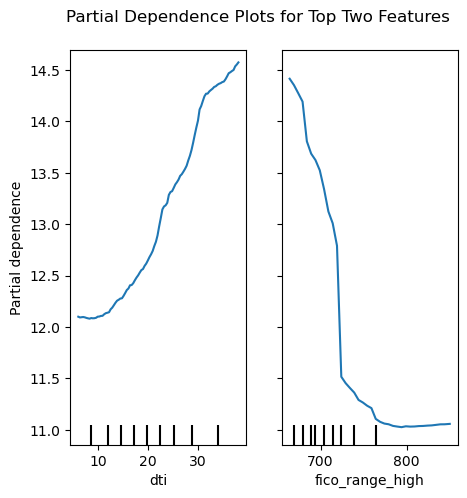

In [372]:
fig, ax = plt.subplots(figsize=(5, 5))

PartialDependenceDisplay.from_estimator(best_rf, X_train, features=top_features, 
                                        feature_names=feature_names, ax=ax)

plt.suptitle('Partial Dependence Plots for Top Two Features')
plt.subplots_adjust(top=0.9)  
plt.show()

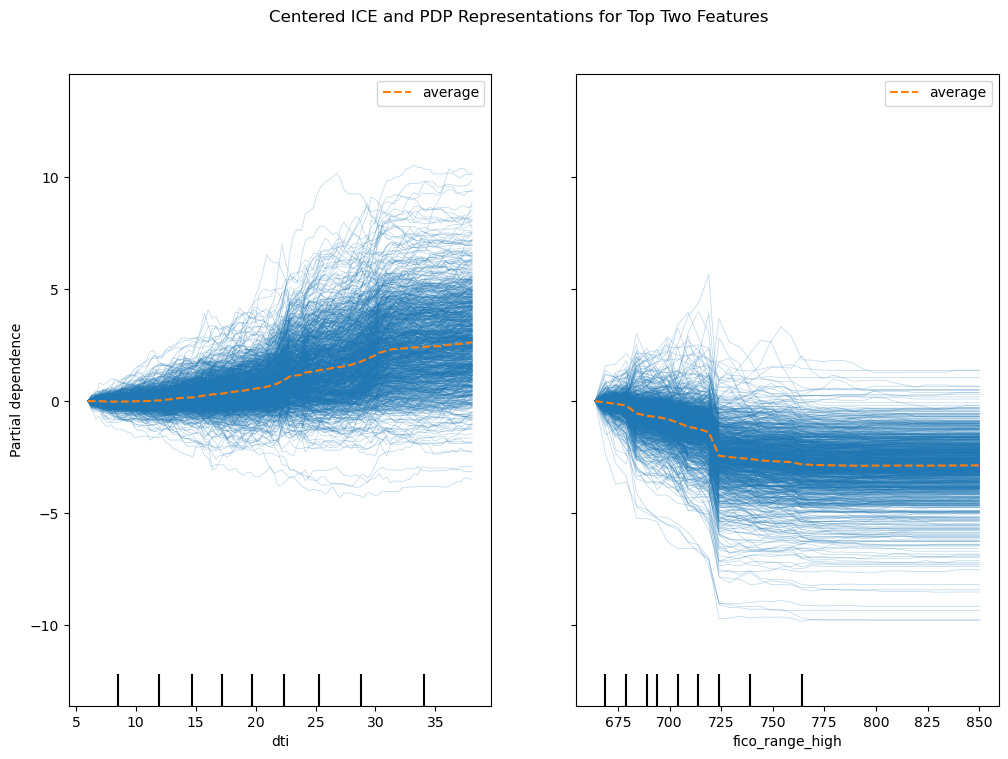

In [375]:
# Create ICE plots for the top 2 most important features
fig, ax = plt.subplots(figsize=(12, 8))

# Assuming best_svm is your trained SVM model
PartialDependenceDisplay.from_estimator(best_rf, X_train, features=top_features,
                                        feature_names=feature_names, ax=ax,
                                        kind="both", centered=True)

plt.suptitle('Centered ICE and PDP Representations for Top Two Features')
plt.subplots_adjust(top=0.9)  # Adjust subtitle position
plt.show()